In [10]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [13]:
! pwd

/Users/alyulina/Projects/Cancer/Code


In [109]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
# samples = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 99, 103, 104, 107, 111, 112, 114]]
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 45)]
samples_t = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

samples_panc = ['SK1_' + '{:0.0f}'.format(i) for i in [94, 95, 99]]
samples_liver = ['SK1_' + '{:0.0f}'.format(i) for i in [103, 104, 107]]
samples_per = ['SK1_' + '{:0.0f}'.format(i) for i in [111, 112, 114]]

samples_2d = ['SK1_' + '{:0.0f}'.format(i) for i in [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]]
# not using amplification replicates for now

In [110]:
sample_clID_counts_3w = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_3w):
    
    sample_clID_counts_3w.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_3w[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_01.09.2023_X202SC22123847-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_3w[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [111]:
sample_clID_counts_pre_inj = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_pre_inj):
    
    sample_clID_counts_pre_inj.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_pre_inj[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_pre_inj[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [112]:
sample_clID_counts_t = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_t):
    
    sample_clID_counts_t.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_t[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_t[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [113]:
sample_clID_counts_panc = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_panc):
    
    sample_clID_counts_panc.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_panc[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_panc[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [114]:
sample_clID_counts_liver = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_liver):
    
    sample_clID_counts_liver.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_liver[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_liver[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [115]:
sample_clID_counts_per = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_per):
    
    sample_clID_counts_per.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_per[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_per[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [116]:
sample_clID_counts_2d = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_2d):
    
    sample_clID_counts_2d.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_2d[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_06.04.2023_X202SC23032115-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_2d[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [117]:
# cancer reads per sample
n_reads_cancer_cells_pre_inj = {}
for i, sample in enumerate(samples_pre_inj):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_pre_inj[i][j]])
        #else:
        #    print(clID_dict.get(j))
            
    n_reads_cancer_cells_pre_inj[sample] = counts     

In [118]:
# cancer reads per sample
n_reads_cancer_cells_t = {}
for i, sample in enumerate(samples_t):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_t[i][j]])
            
    n_reads_cancer_cells_t[sample] = counts     

In [119]:
# cancer reads per sample
n_reads_cancer_cells_3w = {}
for i, sample in enumerate(samples_3w):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_3w[i][j]])
            
    n_reads_cancer_cells_3w[sample] = counts     

In [120]:
# cancer reads per sample
n_reads_cancer_cells_panc = {}
for i, sample in enumerate(samples_panc):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_panc[i][j]])
            
    n_reads_cancer_cells_panc[sample] = counts     

In [26]:
# cancer reads per sample
n_reads_cancer_cells_liver = {}
for i, sample in enumerate(samples_liver):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_liver[i][j]])
            
    n_reads_cancer_cells_liver[sample] = counts     

In [27]:
# cancer reads per sample
n_reads_cancer_cells_per = {}
for i, sample in enumerate(samples_per):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_per[i][j]])
            
    n_reads_cancer_cells_per[sample] = counts     

In [28]:
# cancer reads per sample
n_reads_cancer_cells_2d = {}
for i, sample in enumerate(samples_2d):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_2d[i][j]])
            
    n_reads_cancer_cells_2d[sample] = counts

In [10]:
# 61, 62, 63 are the pre-injection pools (in triplicate)
# 88, 89 are SK1865 rep. 2 and 3
# 90, 91 are SK1879 rep. 2 and 3
# 92, 93 are SK1869 rep. 2 and 3

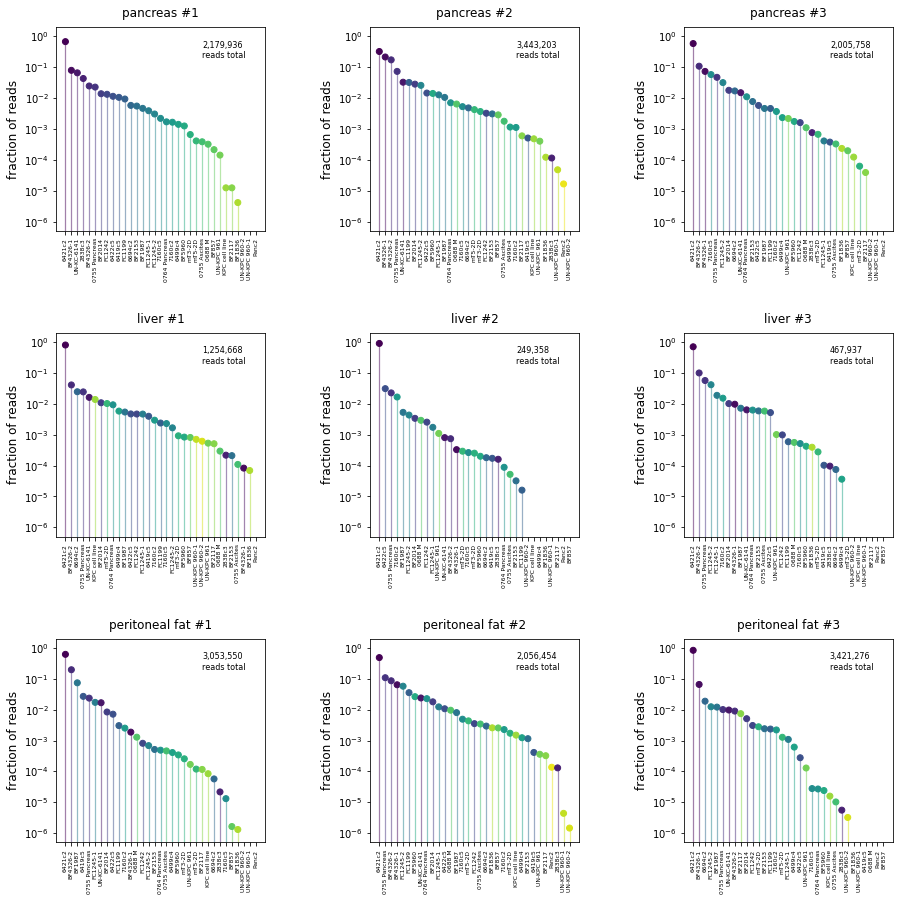

In [81]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 10, 26, 32, 13, 15, 17, 35, 20, 12, 2, 3, 25, 6, 9, 21, 4, 29, 1, 19, 18, 27, 28, 31, 8, 5, 36, 11, 22, 16, 14, 24, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(15, 15))

grid = gridspec.GridSpec(ncols=3, nrows=3,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

for i in range(9):
    
    plt.subplot(grid[i // 3, i % 3])
    
    if i // 3 == 0:
        plt.title('pancreas #' + str(i + 1), fontsize=12, pad=10)
        
        total_coverage = n_reads_cancer_cells_panc[samples_panc[i]] # ignoring the spikes -- there should be no barcodes
        plt.text(23, 0.2,  str(total_coverage)[:-6] + ',' + str(total_coverage)[-6:-3] + ',' + str(total_coverage)[-3:] + '\nreads total', size=8)
        
        bc_frac = []  
        for j in order:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_panc[i][clIDs[j]]])
            bc_frac.append([n_bc_total / total_coverage, j, cell_lines[j].replace('_', ' ')])
        bc_frac_sorted = sorted(bc_frac, reverse=True)
        plt.scatter([x for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted])
        plt.vlines([x for x in range(len(bc_frac_sorted))], [1e-10 for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(bc_frac_sorted))], [x[-1] for x in bc_frac_sorted], fontsize=6, rotation='vertical')

            
    elif i // 3 == 1:
        plt.title('liver #' + str(i + 1 - 3), fontsize=12, pad=10)
        
        total_coverage = n_reads_cancer_cells_liver[samples_liver[i - 3]] # ignoring the spikes -- there should be no barcodes
        if len(str(total_coverage)) >= 7:
            plt.text(23, 0.2,  str(total_coverage)[:-6] + ',' + str(total_coverage)[-6:-3] + ',' + str(total_coverage)[-3:] + '\nreads total', size=8)
        else:
            plt.text(23, 0.2,  str(total_coverage)[:-3] + ',' + str(total_coverage)[-3:] + '\nreads total', size=8)

            
        bc_frac = []  
        for j in order:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_liver[i - 3][clIDs[j]]])
            bc_frac.append([n_bc_total / total_coverage, j, cell_lines[j].replace('_', ' ')])
        bc_frac_sorted = sorted(bc_frac, reverse=True)
        plt.scatter([x for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted])
        plt.vlines([x for x in range(len(bc_frac_sorted))], [1e-10 for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(bc_frac_sorted))], [x[-1] for x in bc_frac_sorted], fontsize=6, rotation='vertical')

        
    elif i // 3 == 2:
        plt.title('peritoneal fat #' + str(i + 1 - 6), fontsize=12, pad=10)
        
        total_coverage = n_reads_cancer_cells_per[samples_per[i - 6]] # ignoring the spikes -- there should be no barcodes
        plt.text(23, 0.2,  str(total_coverage)[:-6] + ',' + str(total_coverage)[-6:-3] + ',' + str(total_coverage)[-3:] + '\nreads total', size=8)
            
        bc_frac = []  
        for j in order:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_per[i - 6][clIDs[j]]])
            bc_frac.append([n_bc_total / total_coverage, j, cell_lines[j].replace('_', ' ')])
        bc_frac_sorted = sorted(bc_frac, reverse=True)
        plt.scatter([x for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted])
        plt.vlines([x for x in range(len(bc_frac_sorted))], [1e-10 for x in range(len(bc_frac_sorted))], [x[0] for x in bc_frac_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in bc_frac_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(bc_frac_sorted))], [x[-1] for x in bc_frac_sorted], fontsize=6, rotation='vertical')

        
        
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-7, 2e0)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fraction of reads', fontsize=12)
      

# plt.savefig('3w_organ-specific_samples_frac_of_reads.png', dpi=300, bbox_inches='tight')    


In [ ]:
# normalizing by pre-injection fractions:

In [96]:
cell_line_fracs_sample_pre_inj = []
for i in range(len(samples_pre_inj)):
    
    total_coverage = n_reads_cancer_cells_pre_inj[samples_pre_inj[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                                   
    cell_line_fracs_sample_pre_inj.append(fracs)


In [100]:
cell_line_fracs_pre_inj = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [0, 23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_pre_inj_i = []
    for j in range(3):
        cell_line_fracs_pre_inj_i.append(cell_line_fracs_sample_pre_inj[j][i])
        
    cell_line_fracs_pre_inj[i] = np.mean(cell_line_fracs_pre_inj_i)

In [82]:
cell_line_fracs_sample_panc = []
for i in range(len(samples_panc)):
    
    total_coverage = n_reads_cancer_cells_panc[samples_panc[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_panc[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                                   
    cell_line_fracs_sample_panc.append(fracs)


In [86]:
cell_line_fracs_sample_liver = []
for i in range(len(samples_liver)):
    
    total_coverage = n_reads_cancer_cells_liver[samples_liver[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_liver[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                                   
    cell_line_fracs_sample_liver.append(fracs)

In [88]:
cell_line_fracs_sample_per = []
for i in range(len(samples_per)):
    
    total_coverage = n_reads_cancer_cells_per[samples_per[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_per[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                                   
    cell_line_fracs_sample_per.append(fracs)


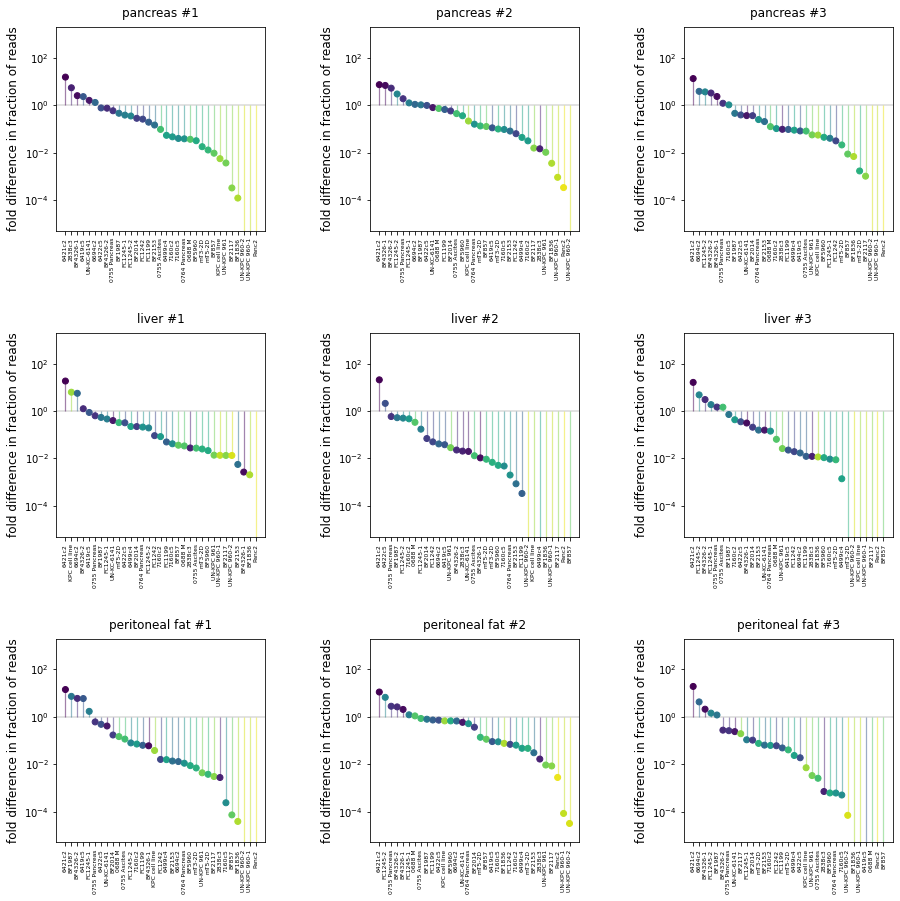

In [108]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 10, 26, 32, 13, 15, 17, 35, 20, 12, 2, 3, 25, 6, 9, 21, 4, 29, 1, 19, 18, 27, 28, 31, 8, 5, 36, 11, 22, 16, 14, 24, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(15, 15))

grid = gridspec.GridSpec(ncols=3, nrows=3,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1], hspace=0.5)

for i in range(9):
    
    plt.subplot(grid[i // 3, i % 3])
    
    if i // 3 == 0:
        plt.title('pancreas #' + str(i + 1), fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_sample_panc[i][cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=6, rotation='vertical')
        
            
    elif i // 3 == 1:
        plt.title('liver #' + str(i + 1 - 3), fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_sample_liver[i - 3][cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=6, rotation='vertical')

        
        
        
    elif i // 3 == 2:
        plt.title('peritoneal fat #' + str(i + 1 - 6), fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_sample_per[i - 6][cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=6, rotation='vertical')

        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-6, 2e3)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in fraction of reads', fontsize=12)
      

# plt.savefig('3w_organ-specific_samples_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


In [ ]:
# 2 day samples:

In [121]:
cell_line_fracs_sample_2d = []
for i in range(len(samples_2d)):
    
    total_coverage = n_reads_cancer_cells_2d[samples_2d[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]:
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_2d[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                                   
    cell_line_fracs_sample_2d.append(fracs)


In [165]:
cell_line_fracs_rag1_2d = {}
cell_line_fracs_f1_2d = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [0, 23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_rag1_2d_i = []
    cell_line_fracs_f1_2d_i = []
    
    for j in range(0, 6):
        cell_line_fracs_rag1_2d_i.append(cell_line_fracs_sample_2d[j][i]) # / (len(range(0, 24)) - 2)
        
    for j in range(6, 16):
        cell_line_fracs_f1_2d_i.append(cell_line_fracs_sample_2d[j][i]) # / len(range(24, 44))
        
    cell_line_fracs_rag1_2d[i] = np.mean(cell_line_fracs_rag1_2d_i)
    cell_line_fracs_f1_2d[i] = np.mean(cell_line_fracs_f1_2d_i)

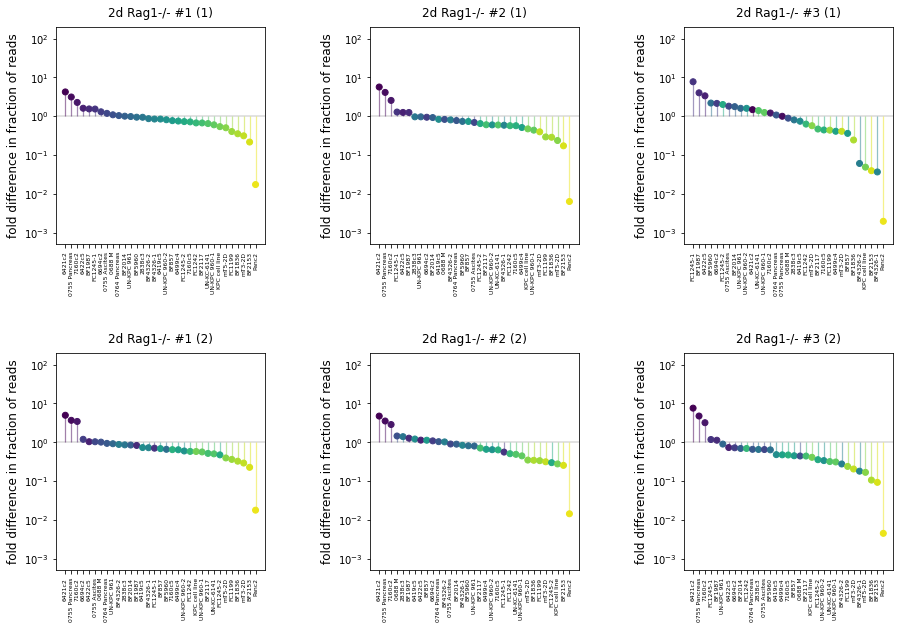

In [163]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(15, 10))

grid = gridspec.GridSpec(ncols=3, nrows=2,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1], hspace=0.5)

for count, i in enumerate([0, 2, 4, 1, 3, 5]):
    
    plt.subplot(grid[count // 3, count % 3])
    
    plt.title('2d Rag1-/- #' + str(i // 2 + 1) + ' (' + str(i % 2 + 1) + ')', fontsize=12, pad=10)
        
    # sorting: 
    fracs = [[cell_line_fracs_sample_2d[i][cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
    fracs_sorted = sorted(fracs, reverse=True)
        
    plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
    plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
    plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=6, rotation='vertical')

        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in fraction of reads', fontsize=12)
      
# plt.savefig('2d_rag1_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


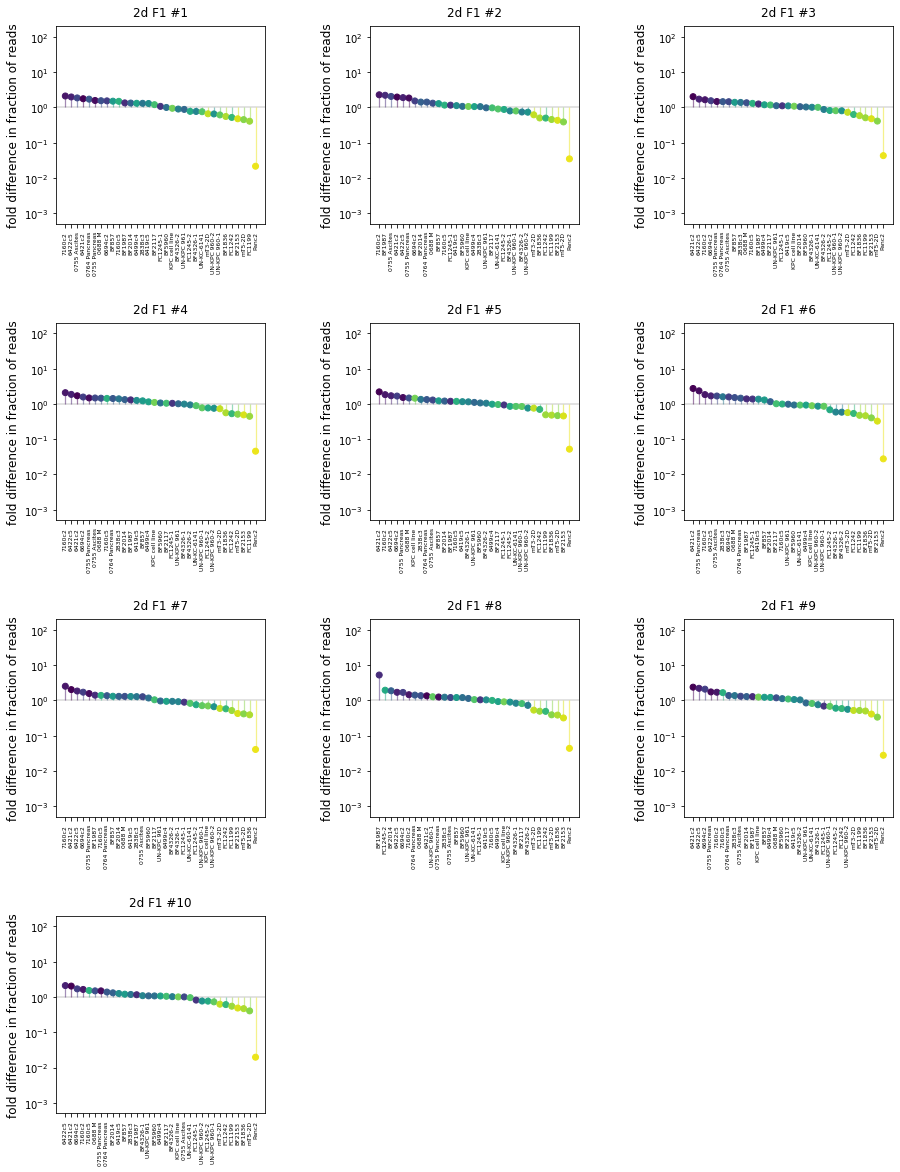

In [164]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(15, 20))

grid = gridspec.GridSpec(ncols=3, nrows=4,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1], hspace=0.5)

for count, i in enumerate(range(6, 16)):
    
    plt.subplot(grid[count // 3, count % 3])
    
    plt.title('2d F1 #' + str(i - 5), fontsize=12, pad=10)
        
    # sorting: 
    fracs = [[cell_line_fracs_sample_2d[i][cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
    fracs_sorted = sorted(fracs, reverse=True)
        
    plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
    plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
    plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=6, rotation='vertical')

        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in fraction of reads', fontsize=12)
      
# plt.savefig('2d_f1_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


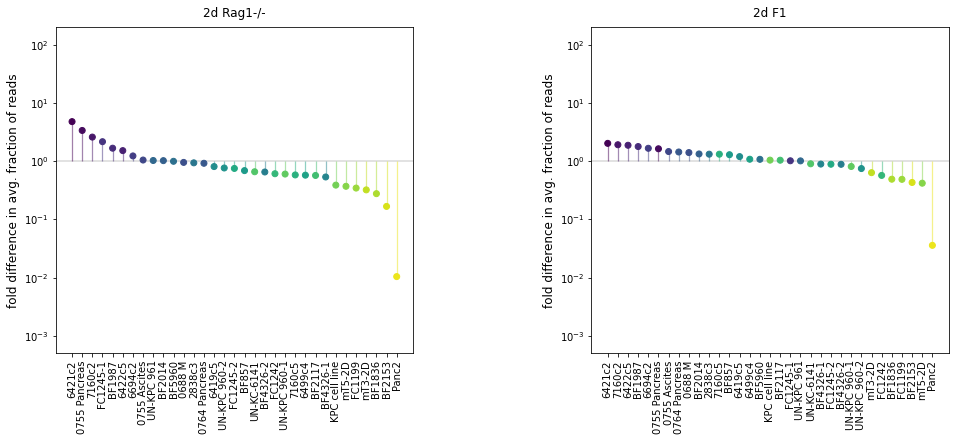

In [180]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(16, 6))

grid = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.2)

for i in range(2):
    
    plt.subplot(grid[i // 2, i % 2])
    
    if i == 0:
        plt.title('2d Rag1-/-', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_rag1_2d[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')

        
        
        
    elif i == 1:
        plt.title('2d F1', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_f1_2d[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')
        
        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in avg. fraction of reads', fontsize=12)
      
# plt.savefig('2d_rag1_f1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


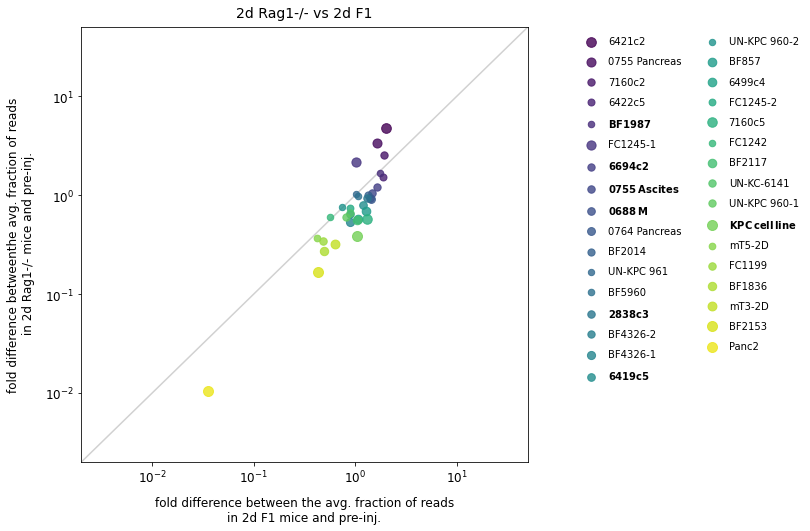

In [188]:
plt.figure(figsize=(8, 8))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]

for count, i in enumerate(order):
    
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
       
    else:
        label = cell_lines[i].replace('_', ' ')
        
    diff = max([cell_line_fracs_f1_2d[cell_lines[i]], cell_line_fracs_rag1_2d[cell_lines[i]]]) / min([cell_line_fracs_f1_2d[cell_lines[i]], cell_line_fracs_rag1_2d[cell_lines[i]]]) 
    #a = min(10 /  diff, 1)
    a=0.8

    plt.scatter(cell_line_fracs_f1_2d[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_rag1_2d[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), label=label, s=min(40 * diff, 100), alpha=a)
    
plt.plot([-100, 1000], [-100, 1000], color='#d1d1d1', zorder=0)

plt.xscale('log'); plt.minorticks_off()
plt.yscale('log'); plt.minorticks_off()

plt.xlim(2e-3, 5e1)
plt.ylim(2e-3, 5e1)

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('fold difference between the avg. fraction of reads\nin 2d F1 mice and pre-inj.', fontsize=12, labelpad=10);
plt.ylabel('fold difference betweenthe avg. fraction of reads\nin 2d Rag1-/- mice and pre-inj.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=1.02, bbox_to_anchor=(1.1, 1));

plt.title('2d Rag1-/- vs 2d F1', pad=10, size=14);

# plt.savefig('2d_rag1_vs_f1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight') 


In [189]:
cell_line_fracs_sample_3w = []
for i in range(len(samples_3w)):
    
    total_coverage = n_reads_cancer_cells_3w[samples_3w[i]] # excluding spike-ins and mT4-2D
    
    fracs = {}
    for j in list(range(len(clIDs))):
        
        if j not in [0, 23, 33, 34]: # excluding spike-ins and mT4-2D
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_3w[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                        
    cell_line_fracs_sample_3w.append(fracs)


In [190]:
cell_line_fracs_rag1_3w = {}
cell_line_fracs_f1_3w = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [0, 23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_rag1_3w_i = []
    cell_line_fracs_f1_3w_i = []
    
    for j in range(0, 24):
        if j == [7, 10] : # excluding samples 8 and 11 
            continue 
        cell_line_fracs_rag1_3w_i.append(cell_line_fracs_sample_3w[j][i]) # / (len(range(0, 24)) - 2)
        
    for j in range(24, 44):
        cell_line_fracs_f1_3w_i.append(cell_line_fracs_sample_3w[j][i]) # / len(range(24, 44))
        
    cell_line_fracs_rag1_3w[i] = np.mean(cell_line_fracs_rag1_3w_i)
    cell_line_fracs_f1_3w[i] = np.mean(cell_line_fracs_f1_3w_i)

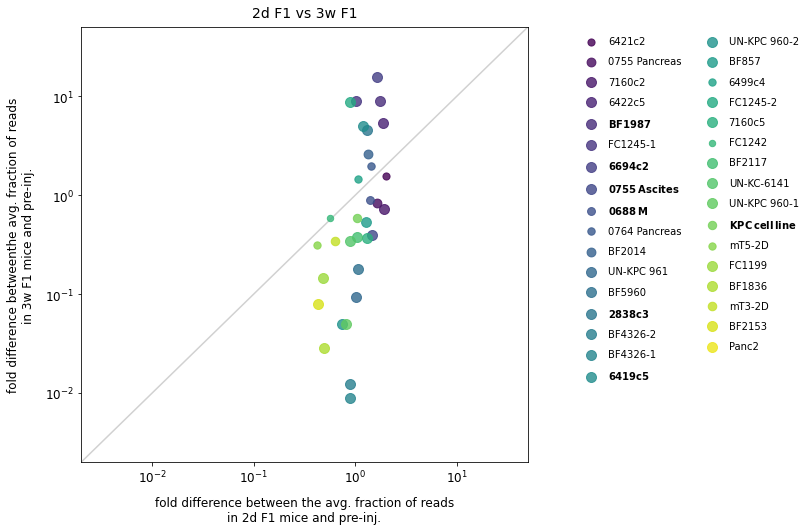

In [194]:
plt.figure(figsize=(8, 8))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]

for count, i in enumerate(order):
    
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
       
    else:
        label = cell_lines[i].replace('_', ' ')
        
    diff = max([cell_line_fracs_f1_2d[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_2d[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) 
    #a = min(10 /  diff, 1)
    a=0.8

    plt.scatter(cell_line_fracs_f1_2d[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), label=label, s=min(40 * diff, 100), alpha=a)
    
plt.plot([-100, 1000], [-100, 1000], color='#d1d1d1', zorder=0)

plt.xscale('log'); plt.minorticks_off()
plt.yscale('log'); plt.minorticks_off()

plt.xlim(2e-3, 5e1)
plt.ylim(2e-3, 5e1)

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('fold difference between the avg. fraction of reads\nin 2d F1 mice and pre-inj.', fontsize=12, labelpad=10);
plt.ylabel('fold difference betweenthe avg. fraction of reads\nin 3w F1 mice and pre-inj.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=1.02, bbox_to_anchor=(1.1, 1));

plt.title('2d F1 vs 3w F1', pad=10, size=14);

# plt.savefig('2d_f1_vs_3w_f1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight') 


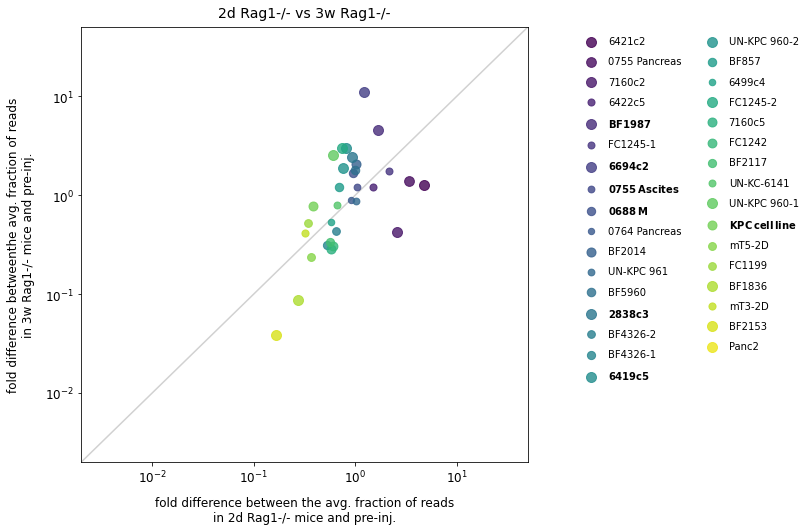

In [224]:
plt.figure(figsize=(8, 8))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]

for count, i in enumerate(order):
    
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
       
    else:
        label = cell_lines[i].replace('_', ' ')
        
    diff = max([cell_line_fracs_rag1_2d[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) / min([cell_line_fracs_rag1_2d[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) 
    #a = min(10 /  diff, 1)
    a=0.8

    plt.scatter(cell_line_fracs_rag1_2d[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), label=label, s=min(40 * diff, 100), alpha=a)
    
plt.plot([-100, 1000], [-100, 1000], color='#d1d1d1', zorder=0)

plt.xscale('log'); plt.minorticks_off()
plt.yscale('log'); plt.minorticks_off()

plt.xlim(2e-3, 5e1)
plt.ylim(2e-3, 5e1)

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('fold difference between the avg. fraction of reads\nin 2d Rag1-/- mice and pre-inj.', fontsize=12, labelpad=10);
plt.ylabel('fold difference betweenthe avg. fraction of reads\nin 3w Rag1-/- mice and pre-inj.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=1.02, bbox_to_anchor=(1.1, 1));

plt.title('2d Rag1-/- vs 3w Rag1-/-', pad=10, size=14);

#plt.savefig('2d_rag1_vs_3w_rag1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight') 


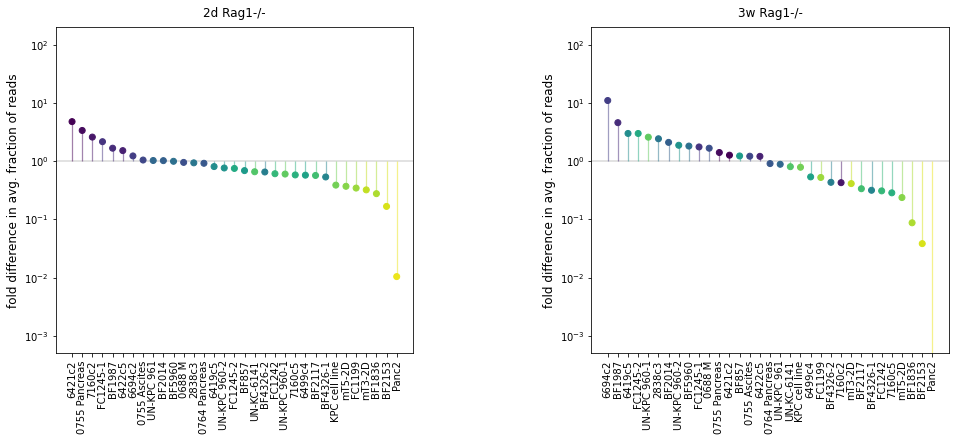

In [197]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(16, 6))

grid = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.2)

for i in range(2):
    
    plt.subplot(grid[i // 2, i % 2])
    
    if i == 0:
        plt.title('2d Rag1-/-', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_rag1_2d[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')

        
        
        
    elif i == 1:
        plt.title('3w Rag1-/-', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_rag1_3w[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')
        
        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in avg. fraction of reads', fontsize=12)
      
# plt.savefig('2d_rag1_3w_rag1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


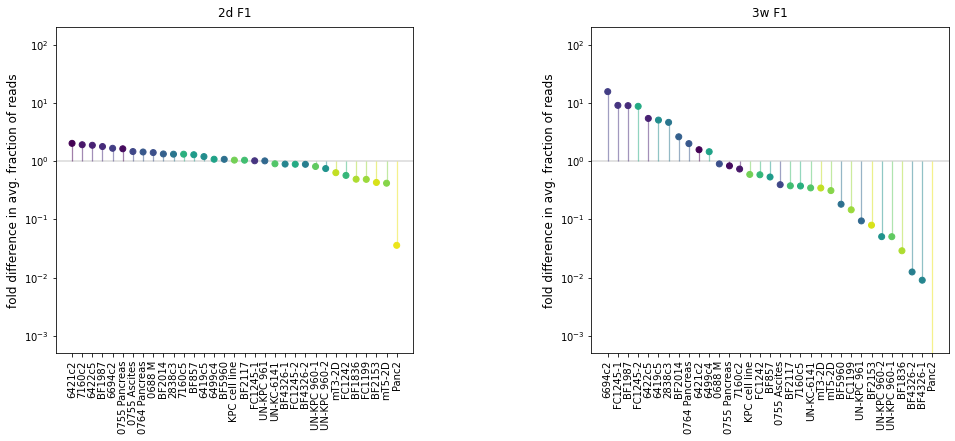

In [198]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(16, 6))

grid = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.2)

for i in range(2):
    
    plt.subplot(grid[i // 2, i % 2])
    
    if i == 0:
        plt.title('2d F1', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_f1_2d[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')

        
        
        
    elif i == 1:
        plt.title('3w F1', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_f1_3w[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')
        
        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in avg. fraction of reads', fontsize=12)
      
# plt.savefig('2d_f1_3w_f1_avg_frac_of_reads_norm_by_avg_pre-inj.png', dpi=300, bbox_inches='tight')    


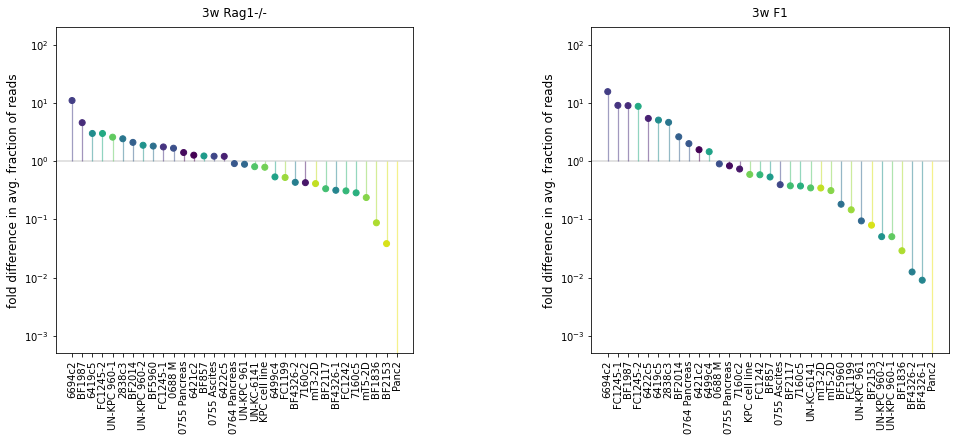

In [226]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)-4), 
                                       cmap=plt.get_cmap('viridis'))

# based on panc sample 1
order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]
colors = dict(zip(order, [viridis.to_rgba(i) for i in range(len(order))]))

plt.figure(figsize=(16, 6))

grid = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.2)

for i in range(2):
    
    plt.subplot(grid[i // 2, i % 2])
    
    if i == 0:
        plt.title('3w Rag1-/-', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_rag1_3w[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')

        
        
        
    elif i == 1:
        plt.title('3w F1', fontsize=12, pad=10)
        
        # sorting: 
        fracs = [[cell_line_fracs_f1_3w[cell_lines[j]] / cell_line_fracs_pre_inj[cell_lines[j]], j, cell_lines[j].replace('_', ' ')] for j in order]
        fracs_sorted = sorted(fracs, reverse=True)
        
        plt.scatter([x for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted])
        plt.vlines([x for x in range(len(fracs_sorted))], [1 for x in range(len(fracs_sorted))], [x[0] for x in fracs_sorted], color=[viridis.to_rgba(order.index(x[1])) for x in fracs_sorted], alpha=0.5, linewidth=1.25)
        
        plt.xticks([x for x in range(len(fracs_sorted))], [x[-1] for x in fracs_sorted], fontsize=10, rotation='vertical')
        
        
        
        
    plt.axhline(y=1, color='#d9d9d9', zorder=0)
    
    plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(5e-4, 2e2)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    # plt.xticks([j for j in range(len(order))], [cell_lines[j] for j in order], fontsize=6, rotation='vertical')
    
    # plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fold difference in avg. fraction of reads', fontsize=12)
      
# plt.savefig('3w_rag1_3w_f1_avg_frac_of_reads_norm_by_avg_pre-inj-2.png', dpi=300, bbox_inches='tight')    


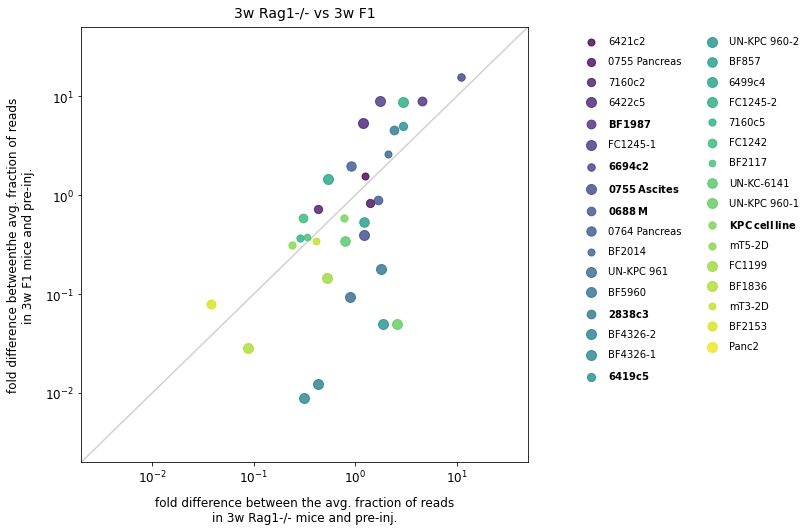

In [232]:
plt.figure(figsize=(8, 8))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [30, 15, 1, 20, 6, 9, 3, 31, 8, 29, 17, 36, 18, 32, 13, 10, 12, 24, 5, 19, 21, 4, 35, 11, 26, 14, 22, 28, 2, 16, 27, 25, 7]

for count, i in enumerate(order):
    
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
       
    else:
        label = cell_lines[i].replace('_', ' ')
        
    diff = max([cell_line_fracs_rag1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) / min([cell_line_fracs_rag1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) 
    #a = min(10 /  diff, 1)
    a=0.8

    plt.scatter(cell_line_fracs_rag1_3w[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]] / cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), label=label, s=min(40 * diff, 100), alpha=a)
    
plt.plot([-100, 1000], [-100, 1000], color='#d1d1d1', zorder=0)

plt.xscale('log'); plt.minorticks_off()
plt.yscale('log'); plt.minorticks_off()

plt.xlim(2e-3, 5e1)
plt.ylim(2e-3, 5e1)

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('fold difference between the avg. fraction of reads\nin 3w Rag1-/- mice and pre-inj.', fontsize=12, labelpad=10);
plt.ylabel('fold difference betweenthe avg. fraction of reads\nin 3w F1 mice and pre-inj.', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=1.02, bbox_to_anchor=(1.1, 1));

plt.title('3w Rag1-/- vs 3w F1', pad=10, size=14);

#plt.savefig('3w_rag1_vs_3w_f1_avg_frac_of_reads_norm_by_avg_pre-inj-2.png', dpi=300, bbox_inches='tight') 


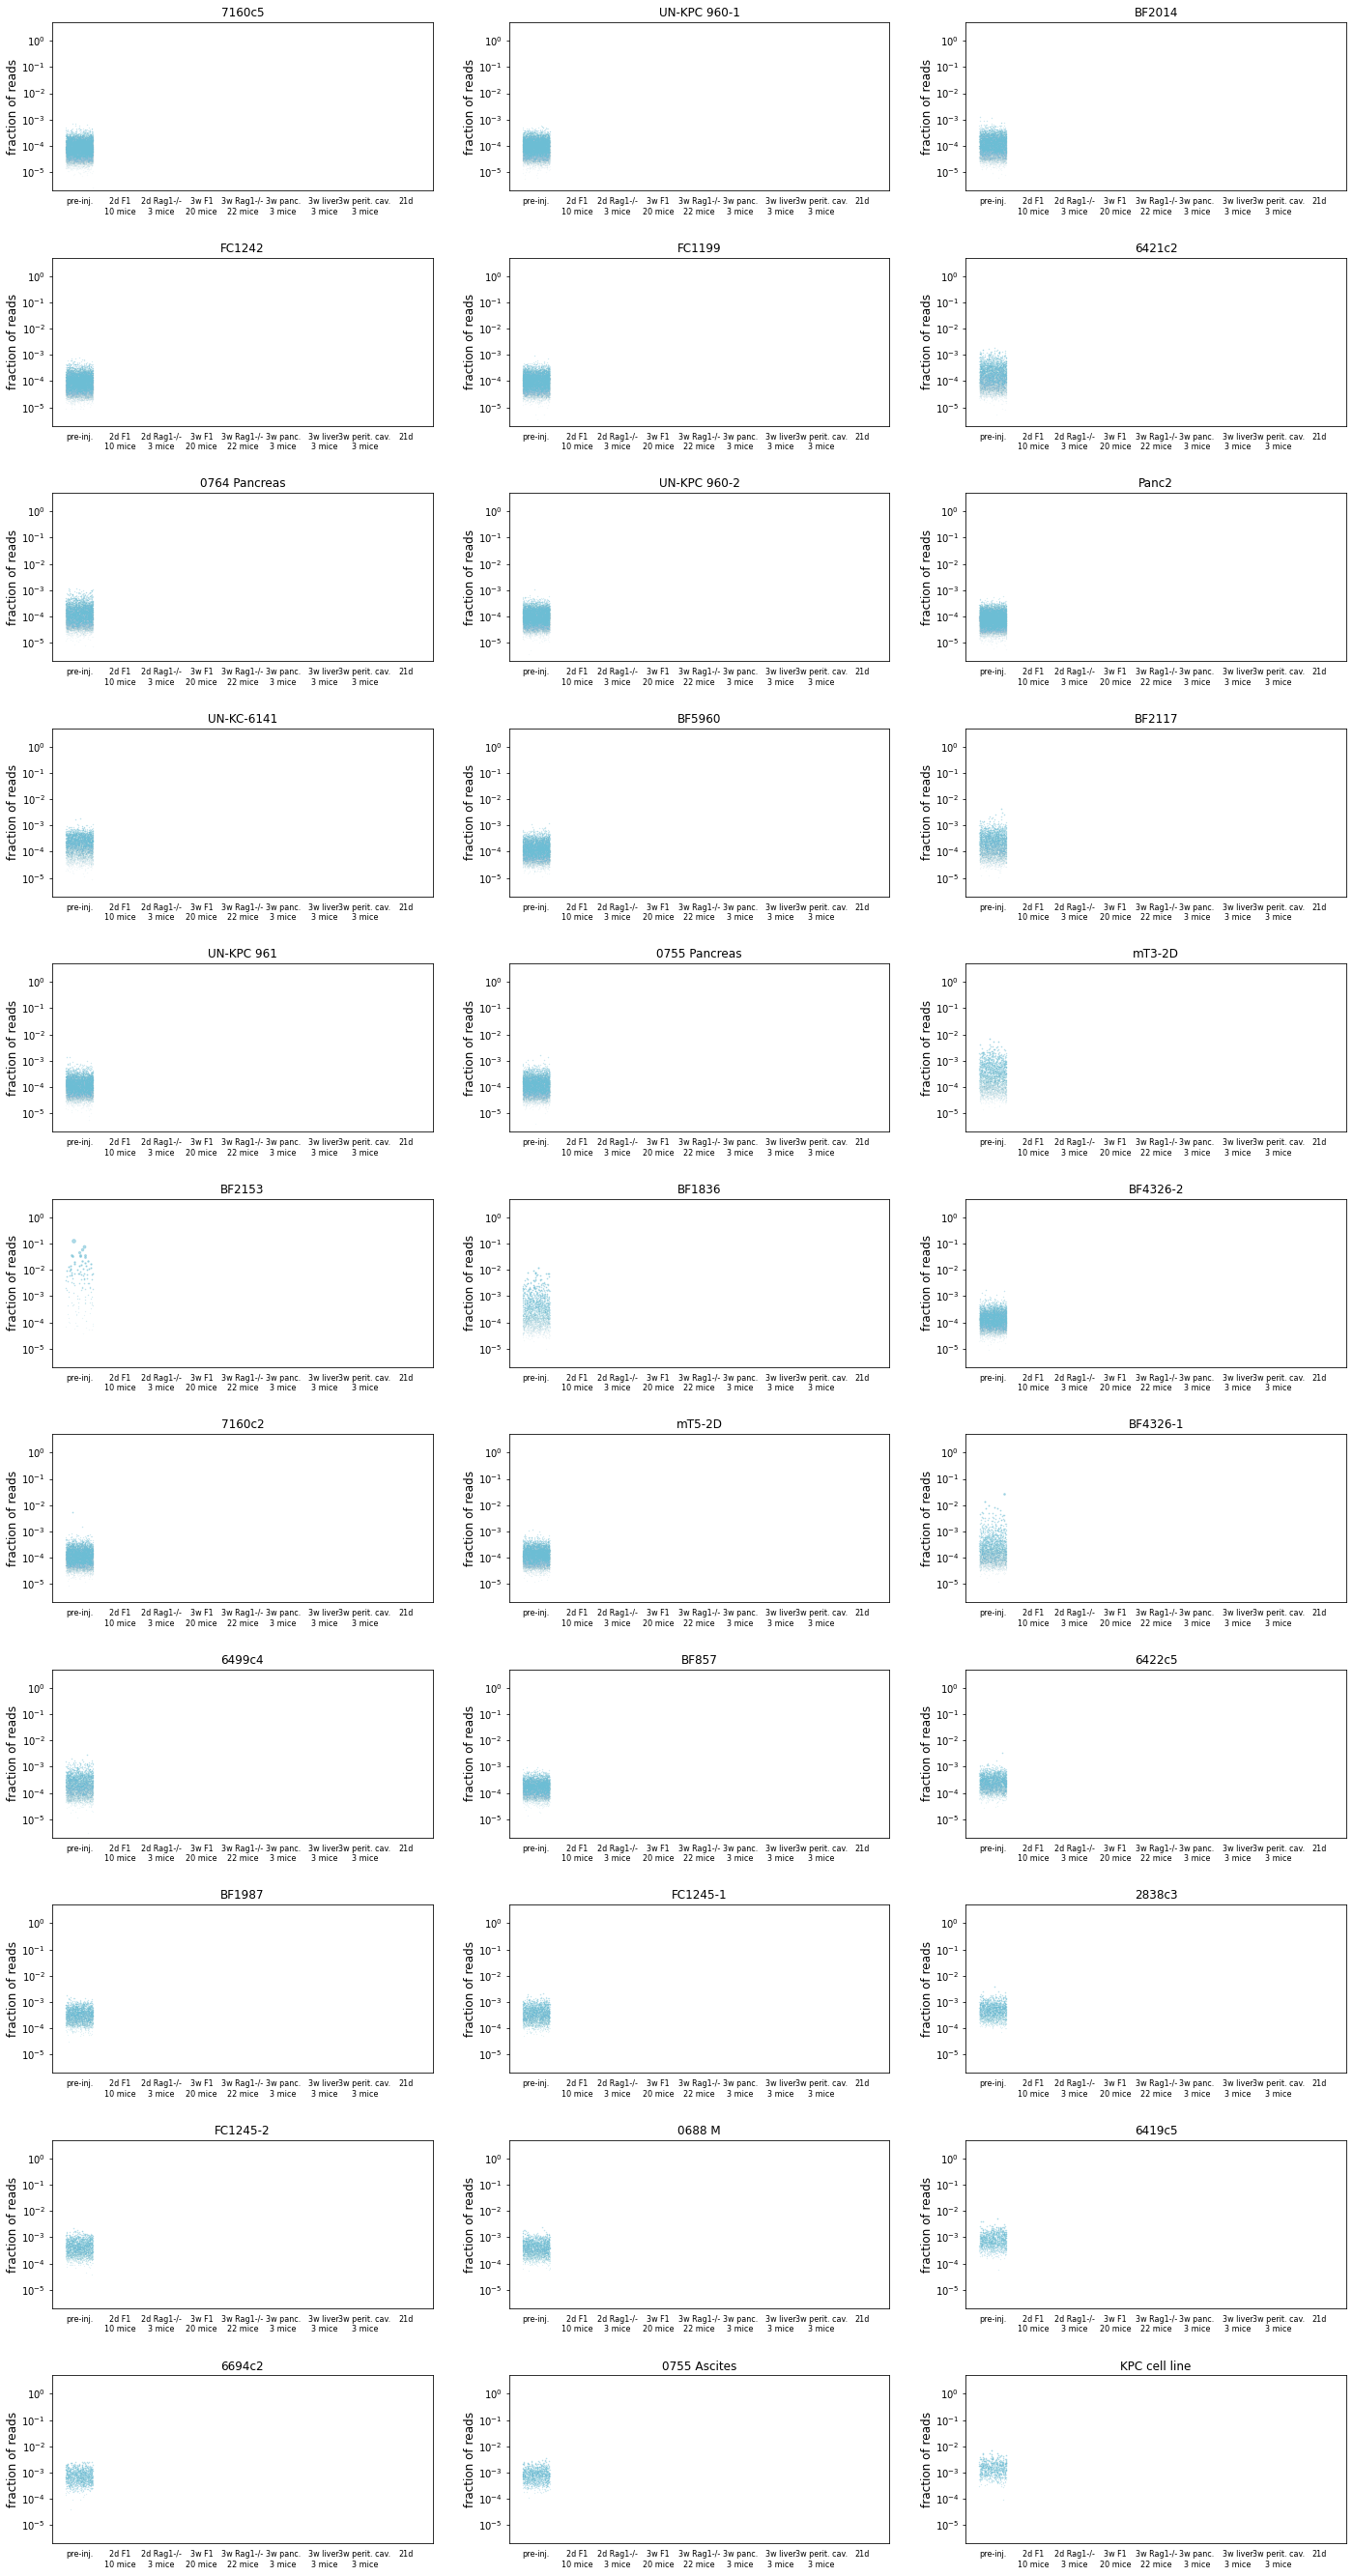

In [216]:
plt.figure(figsize=(24, 48))

grid = gridspec.GridSpec(ncols=3, nrows=11,
                         width_ratios=[1, 1, 1], wspace=0.2,
                         height_ratios=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], hspace=0.4)

order = [4, 14, 17, 35, 2, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

for count, i in enumerate(order):
    
    plt.subplot(grid[count // 3, count % 3])
    plt.title(cell_lines[i].replace('_', ' '), size=12)
    
    
    # only plotting pre-inj. rep.3 or sample_clID_counts_pre_inj[2]
    bc_i = [x[-1] for x in sample_clID_counts_pre_inj[2][clIDs[i]]]
    bc_counts_i = [[x, bc_i.count(x)] for x in set(bc_i)] 

    
    for j in bc_counts_i:
        plt.scatter(np.random.uniform(0, 1, j[-1]), [x for x in np.random.normal(j[0] / sum(bc_i), 0.5 / sum(bc_i), j[-1])], color='#6cbdd4', edgecolors=None,
                    s=1e2*j[0] / sum(bc_i), alpha=0.5)

#    # all F1 mice together
#    for m in range(25, 44):
#        bc_i = [x[-1] for x in sample_clID_counts_3w[m][clIDs[i]]]
#        bc_counts_i = [[x, bc_i.count(x)] for x in set(bc_i)] 
#    
#        for j in bc_counts_i:
#            plt.scatter(np.random.uniform(1.5, 2.5, j[-1]), [x for x in np.random.normal(j[0] / sum(bc_i), 0.5 / sum(bc_i), j[-1])], color='#6cbdd4', edgecolors=None,
#                        s=1e2*j[0] / sum(bc_i), alpha=0.5)
#            
#    # all Rag1-/- mice together excluding samples 8 and 11
#    for m in range(25):
#        if m in [7, 10]:
#            continue
#        
#        bc_i = [x[-1] for x in sample_clID_counts_3w[m][clIDs[i]]]
#        bc_counts_i = [[x, bc_i.count(x)] for x in set(bc_i)] 
#    
#        for j in bc_counts_i:
#            plt.scatter(np.random.uniform(3, 4, j[-1]), [x for x in np.random.normal(j[0] / sum(bc_i), 0.5 / sum(bc_i), j[-1])], color='#6cbdd4', edgecolors=None,
#                        s=1e2*j[0] / sum(bc_i), alpha=0.5)
#            
#    # t=8, rep. 3
#    bc_i = [x[-1] for x in sample_clID_counts_t[-1][clIDs[i]]]
#    bc_counts_i = [[x, bc_i.count(x)] for x in set(bc_i)] 
#    
#    for j in bc_counts_i:
#        plt.scatter(np.random.uniform(4.5, 5.5, j[-1]), [x for x in np.random.normal(j[0] / sum(bc_i), 0.5 / sum(bc_i), j[-1])], color='#6cbdd4', edgecolors=None,
#                    s=1e2*j[0] / sum(bc_i), alpha=0.5)

           
    
    plt.ylim(2e-6, 5)
    plt.yscale('log'); plt.minorticks_off()
    plt.yticks(size=10)
    
    #if count % 5 == 0:
    plt.ylabel('fraction of reads', size=12, labelpad=2);

    plt.tick_params(bottom=False)
    plt.xlim(-0.5, 13.5)
    plt.xticks([0.5, 2, 3.5, 5, 6.5, 8, 9.5, 11, 12.5], ['pre-inj.', '2d F1\n10 mice', '2d Rag1-/-\n3 mice', '3w F1\n20 mice', '3w Rag1-/-\n22 mice', '3w panc.\n3 mice', '3w liver\n3 mice', '3w perit. cav.\n3 mice', '21d'], size=8)
    #plt.xticks([0, 1, 2, 3, 4, 5, 6], [0, 1, 2, 3, 4, 5, 6])
    #plt.vlines([0, 1, 1.5, 2.5, 3, 4, 4.5, 5.5], 0, 2)

    
 

   
        
# plt.savefig('pre-inj_bc_distr_scatter_normalized_all_cell_lines-2.png', dpi=300, bbox_inches='tight')



In [220]:
bc_i = [x[-1] for x in sample_clID_counts_pre_inj[2][clIDs[4]]]

In [222]:
bc_counts_i = [[x, bc_i.count(x)] for x in set(bc_i)] 

In [223]:
sample_clID_counts_pre_inj[2][clIDs[4]]

[['GCCGTCGGCGTGGTAG', 3],
 ['TCTGTAAGTAGGACTG', 3],
 ['GAGGCTAGCAGGCCCG', 2],
 ['TCTGTGAGAGCGGCTG', 2],
 ['TGTGCTAGGTGGGGCG', 3],
 ['GTAGCGAGTCGGGAGG', 2],
 ['ATCGTGGGCTGGGGAG', 2],
 ['TCTGGCCGTCGGGGAG', 2],
 ['CGAGCTAGGGTGCGCG', 2],
 ['TTAGGGTGGAGGGAAG', 2],
 ['TCAGTCCGCACGGATG', 2],
 ['TAGGGTGGGCGGTCAG', 2],
 ['TGTGTCAGGAGGTCGG', 2],
 ['TAGGTCAGTGGGAGGG', 2],
 ['CTGGGGGGGAGGATGG', 2],
 ['GCTGAATGAGGGTACG', 2],
 ['CTTGCGTGAGGGGATG', 2],
 ['GAAGGTAGTTCGTAAG', 2],
 ['CAAGCCAGTATGTCTG', 2],
 ['TAAGGAGGGCGGATAG', 2],
 ['AATGACAGGGAGTACG', 2],
 ['TCAGCGGGAGTGATAG', 2],
 ['GAGGCAAGATTGGAGG', 2],
 ['TGAGAGAGAAAGGGGG', 2],
 ['GAGGAGAGTCCGCAGG', 2],
 ['GCAGAGAGATGGCCCG', 2],
 ['GAAGGGGGCTTGTTAG', 2],
 ['TCTGCCGGACGGCAGG', 3],
 ['TCGGATGGTCAGTAAG', 4],
 ['TTAGGCAGTGGGTAGG', 2],
 ['AGGGGGGGAAAGTGCG', 2],
 ['CAGGACTGGGGGATTG', 2],
 ['ATCGGTAGAATGGCGG', 4],
 ['ATAGTTTGTACGTGGG', 3],
 ['AGAGTAGGGCAGATGG', 3],
 ['TGTGTTAGCTCGCAGG', 2],
 ['GTGGCCGGAAAGTCGG', 2],
 ['TCAGGCGGAAAGCTTG', 2],
 ['AAGGTTCGA